In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df=pd.read_csv('cardekho_dataset.csv',index_col=[0])
df.head()

,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15411 entries, 0 to 19543
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   car_name           15411 non-null  object 
 1   brand              15411 non-null  object 
 2   model              15411 non-null  object 
 3   vehicle_age        15411 non-null  int64  
 4   km_driven          15411 non-null  int64  
 5   seller_type        15411 non-null  object 
 6   fuel_type          15411 non-null  object 
 7   transmission_type  15411 non-null  object 
 8   mileage            15411 non-null  float64
 9   engine             15411 non-null  int64  
 10  max_power          15411 non-null  float64
 11  seats              15411 non-null  int64  
 12  selling_price      15411 non-null  int64  
dtypes: float64(2), int64(5), object(6)
memory usage: 1.6+ MB


In [ ]:
# Numerical columns
numeric_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Categorical columns
categorical_features = df.select_dtypes(include=['object', 'category']).columns.tolist()

print(f'We have {len(numeric_features)} numerical features: {numeric_features}')
print(f'We have {len(categorical_features)} categorical features: {categorical_features}')


We have 7 numerical features: ['vehicle_age', 'km_driven', 'mileage', 'engine', 'max_power', 'seats', 'selling_price']
We have 6 categorical features: ['car_name', 'brand', 'model', 'seller_type', 'fuel_type', 'transmission_type']


In [ ]:
#proportion of each unique values of categorical column
for col in categorical_features:
  print(df[col].value_counts(normalize=True)*100)
  print('--------------------------------------')

car_name
Hyundai i20              5.878918
Maruti Swift Dzire       5.775096
Maruti Swift             5.067809
Maruti Alto              5.048342
Honda City               4.912076
                           ...   
Mercedes-AMG C           0.006489
Rolls-Royce Ghost        0.006489
Maserati Quattroporte    0.006489
Isuzu MUX                0.006489
Force Gurkha             0.006489
Name: proportion, Length: 121, dtype: float64
--------------------------------------
brand
Maruti           32.392447
Hyundai          19.349815
Honda             9.635974
Mahindra          6.560249
Toyota            5.145675
Ford              5.126209
Volkswagen        4.023100
Renault           3.478035
BMW               2.848615
Tata              2.790215
Mercedes-Benz     2.186750
Skoda             2.167283
Audi              1.245863
Datsun            1.103108
Jaguar            0.382843
Land Rover        0.330932
Jeep              0.266044
Kia               0.207644
Porsche           0.136266
Volvo        

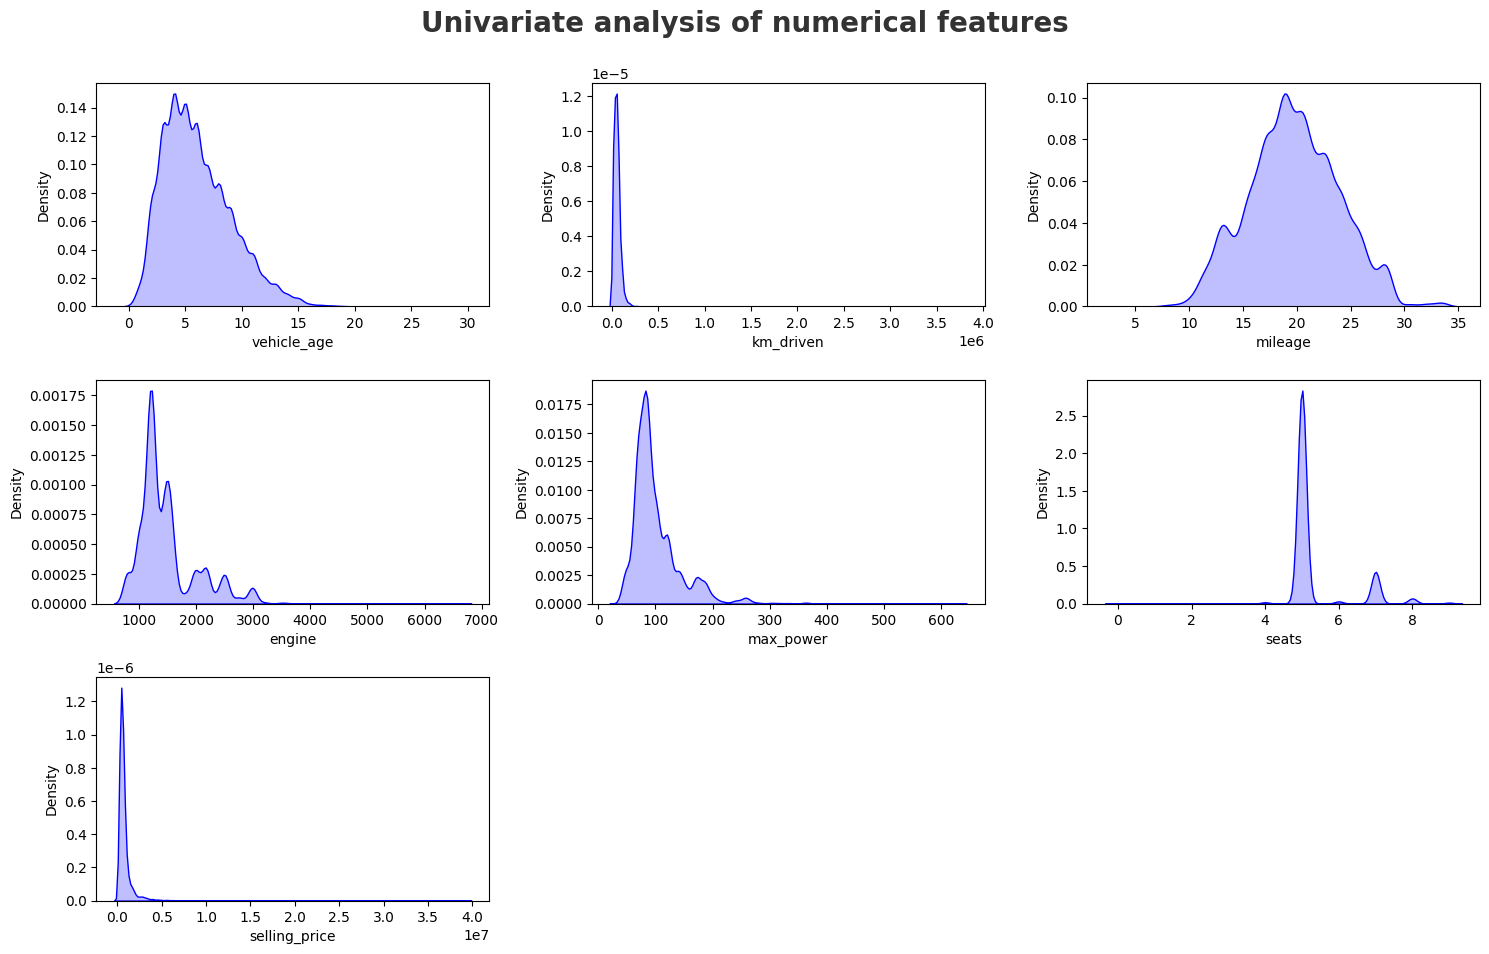

In [ ]:
#Univariate analysis of numerical features
plt.figure(figsize=(15,15))
plt.suptitle('Univariate analysis of numerical features',fontsize=20,fontweight='bold',alpha=0.8,y=1)

for i in range(0,len(numeric_features)):
  plt.subplot(5,3,i+1)
  sns.kdeplot(x=df[numeric_features[i]],fill=True,color='b')
  plt.xlabel(numeric_features[i])
  plt.tight_layout()

| Feature       | Shape            | Action            | Model         |
| ------------- | ---------------- | ----------------- | ------------- |
| selling_price | Heavy right-skew | log1p             | XGBoost       |
| km_driven     | Heavy right-skew | log               | Random Forest |
| engine        | Multi-modal      | none              | Tree          |
| seats         | Discrete         | treat categorical | Tree          |
| mileage       | Near normal      | scale             | Linear ok     |
this is for understanding which ml model used based on  type of distribution

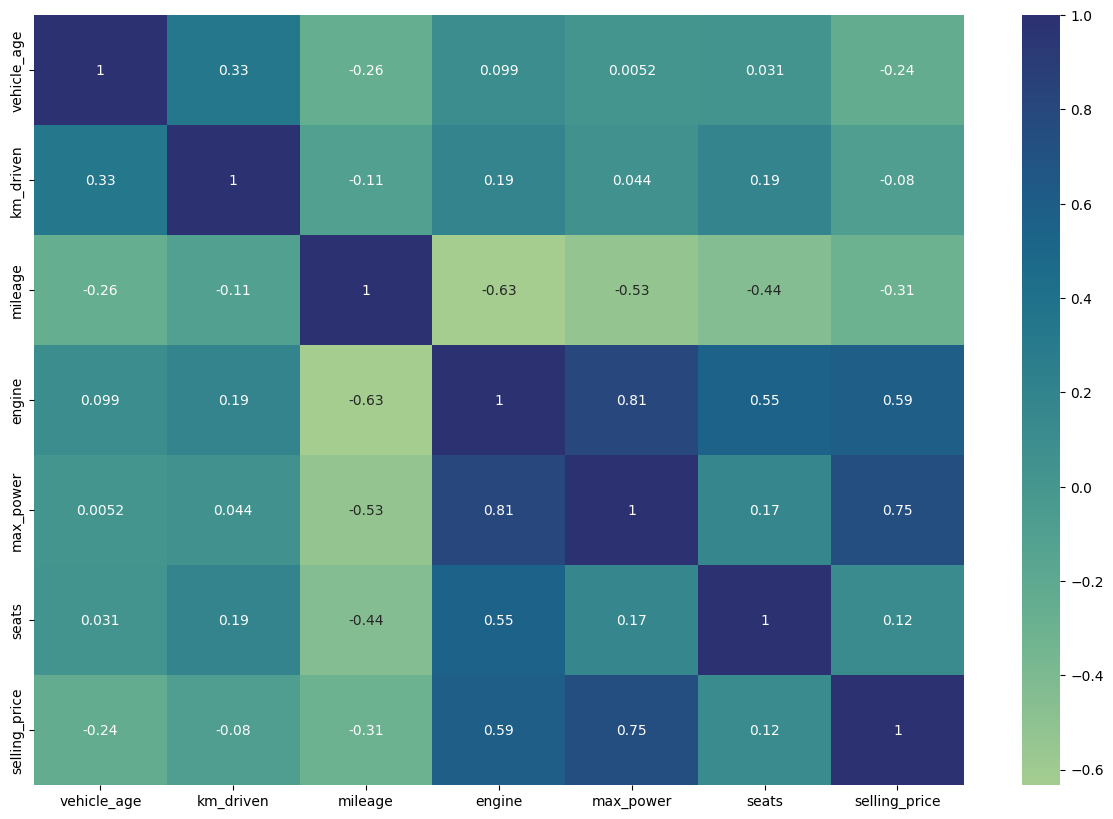

In [ ]:
df_corr=df.drop(columns=['car_name','brand','model','seller_type','fuel_type','transmission_type'],axis=1).corr()
plt.figure(figsize=(15,10))
sns.heatmap(df_corr,cmap='crest',annot=True)
plt.show()

Report


*   Milage and Engine are negatively correlated
*   Max power has highest positive correlation with target variable selling_price


*   km_driven has least correlation with target variable






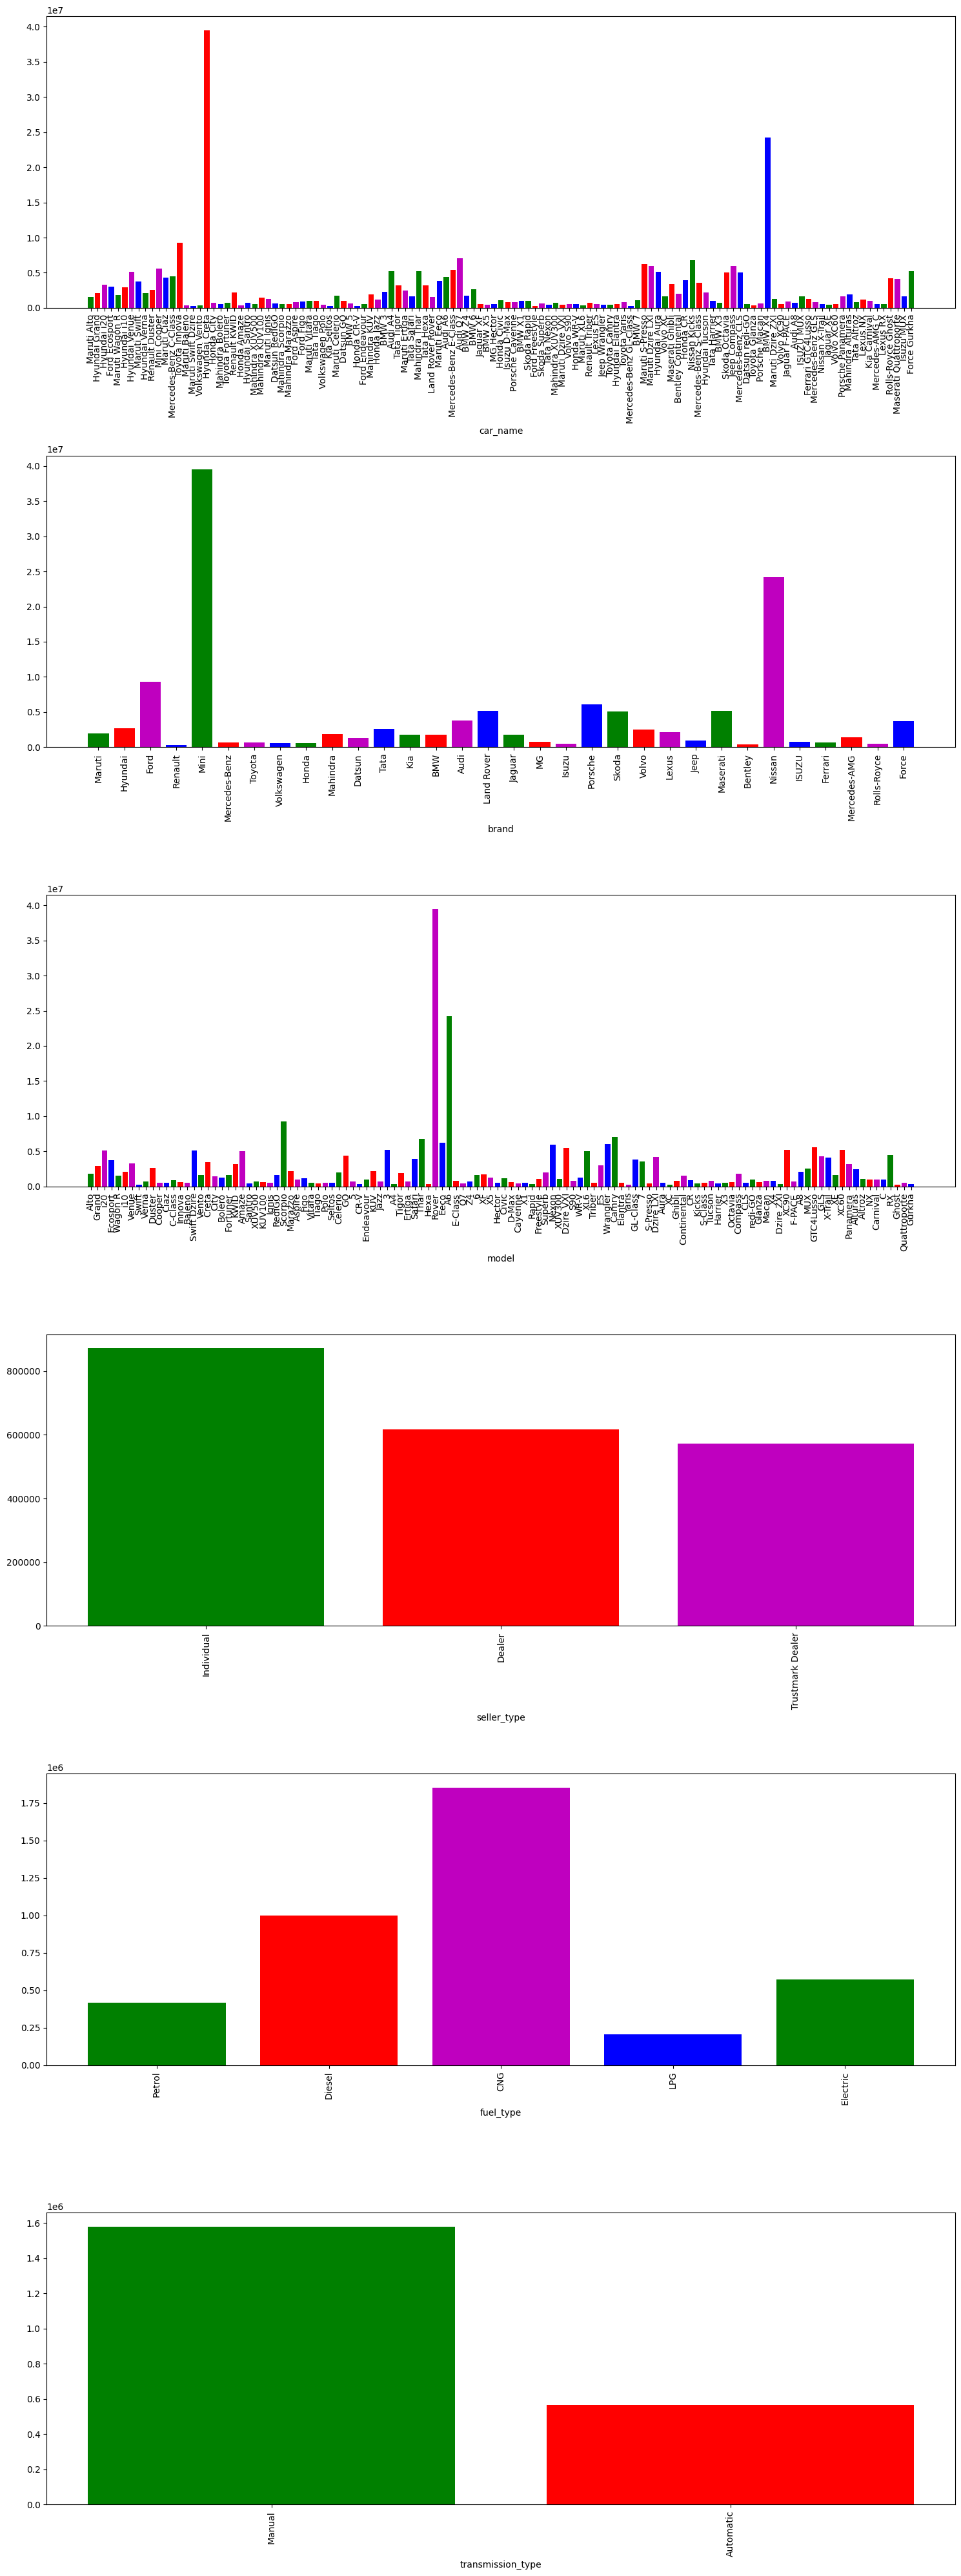

In [ ]:
plt.figure(figsize=(15,40))
colors=['g','r','m','b']
for i in range(0,len(categorical_features)):
  plt.subplot(6,1,i+1)
  cat_list=df[categorical_features[i]].unique()
  #use 'selling_price' as the valur column in groupby and calculate the mean.
  cat_average=df.groupby(categorical_features[i])['selling_price'].mean()
  plt.bar(cat_list,cat_average,color=colors)
  plt.xlabel(categorical_features[i])
  plt.xticks(rotation=90)
plt.tight_layout()

In [ ]:
df.isnull().sum()

,0
car_name,0
brand,0
model,0
vehicle_age,0
km_driven,0
seller_type,0
fuel_type,0
transmission_type,0
mileage,0
engine,0


In [ ]:
#continuous features and selling price
continuous_features=[feature for feature in numeric_features if len(df[feature].unique())>=30]
print('Name of continuous features: ',continuous_features)

Name of continuous features:  ['km_driven', 'mileage', 'engine', 'max_power', 'selling_price']


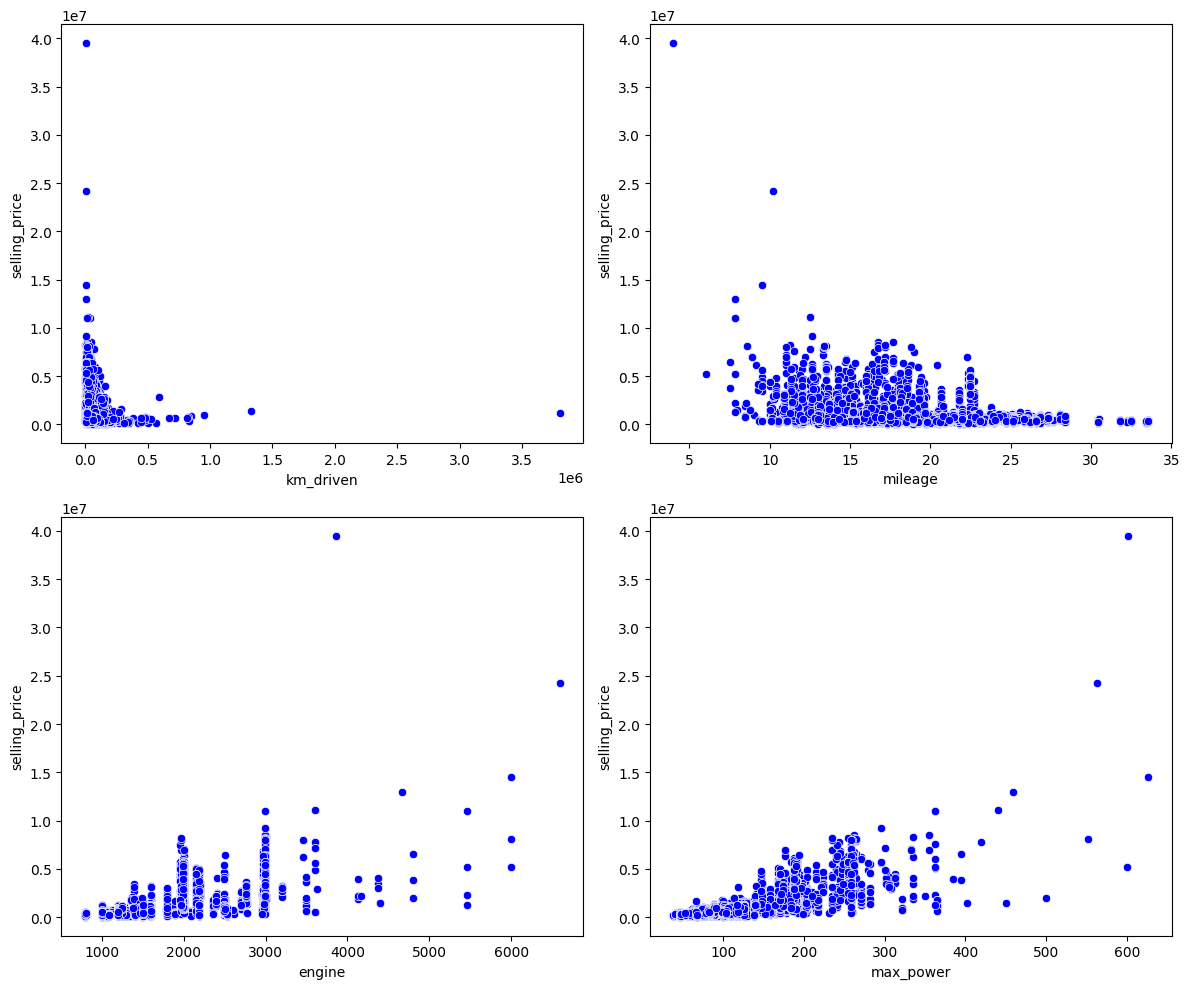

In [ ]:
fig=plt.figure(figsize=(12,10))
for i in range(0,len(continuous_features)):
  if continuous_features[i] != 'selling_price':
    ax=plt.subplot(2,2,i+1)
    sns.scatterplot(data=df,y='selling_price',x=continuous_features[i],color='b')
    plt.tight_layout()

**Report**
- km_driven has -ve relationship
- Engine cc has +ve relationship
- Milage has low -ve correlation
- Max power has +ve correlation
- There are relationship between all continuous and target column

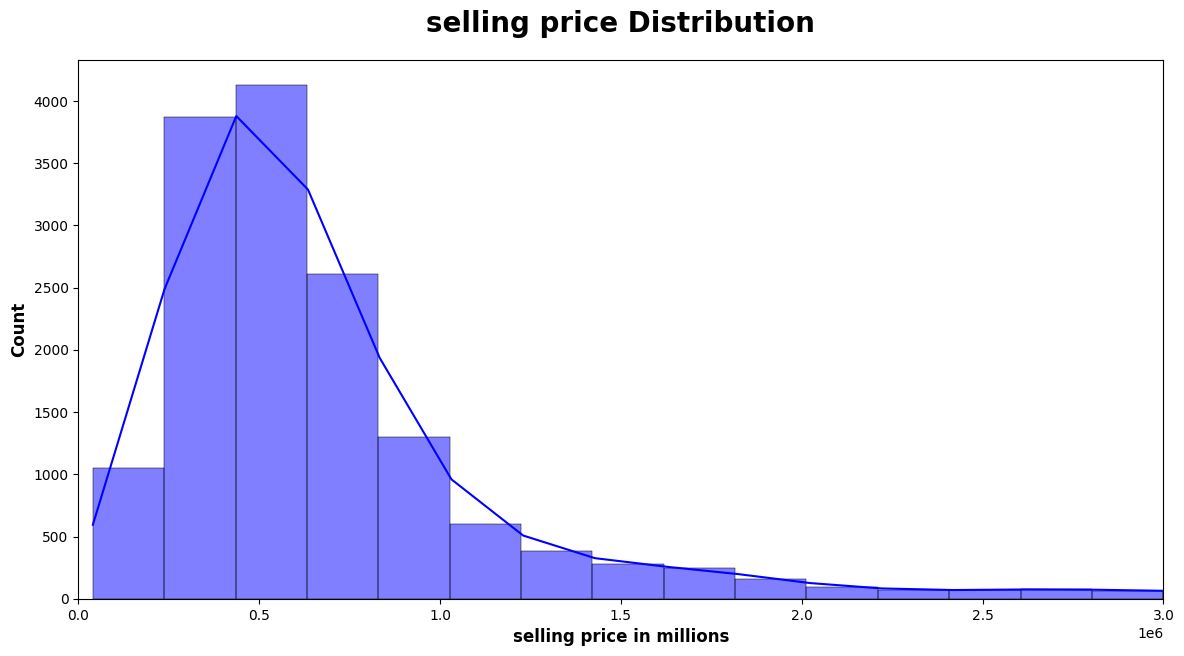

In [ ]:
#Visualize the target feature
plt.subplots(figsize=(14,7))
sns.histplot(df.selling_price,bins=200,kde=True,color='b')
plt.title('selling price Distribution',weight='bold',fontsize=20,pad=20)
plt.ylabel('Count',weight='bold',fontsize=12)
plt.xlabel('selling price in millions',weight='bold',fontsize=12)
plt.xlim(0,3000000)
plt.show()

from the chart it is clear that the target variable skewed

In [ ]:
#most selling cars
df.car_name.value_counts()[0:10]

,count
car_name,
Hyundai i20,906
Maruti Swift Dzire,890
Maruti Swift,781
Maruti Alto,778
Honda City,757
Maruti Wagon R,717
Hyundai Grand,580
Toyota Innova,545
Hyundai Verna,492


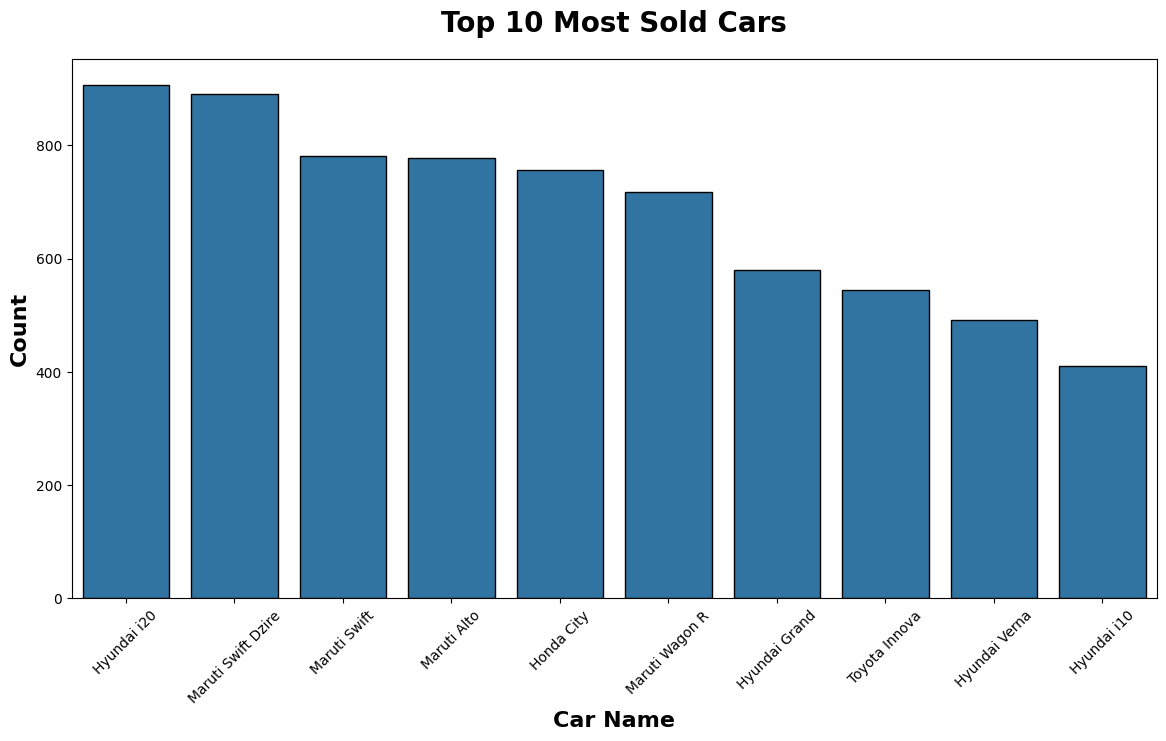

In [ ]:
plt.figure(figsize=(14,7))

sns.countplot(
    x='car_name',
    data=df,
    ec='black',
    order=df['car_name'].value_counts().head(10).index
)

plt.title('Top 10 Most Sold Cars', weight='bold', fontsize=20, pad=20)
plt.ylabel('Count', weight='bold', fontsize=16)
plt.xlabel('Car Name', weight='bold', fontsize=16)
plt.xticks(rotation=45)
plt.show()


In [ ]:
#Checkmean price of hyundai i20 which is fmost used
i20=df[df['car_name'] == 'Hyundai i20']['selling_price'].mean()
print(f'The mean price of hyundai i20 is {i20:.2f} Rupees')

The mean price of hyundai i20 is 543603.75 Rupees


In [ ]:
#most selling brand
df.brand.value_counts()[0:10]

,count
brand,
Maruti,4992
Hyundai,2982
Honda,1485
Mahindra,1011
Toyota,793
Ford,790
Volkswagen,620
Renault,536
BMW,439


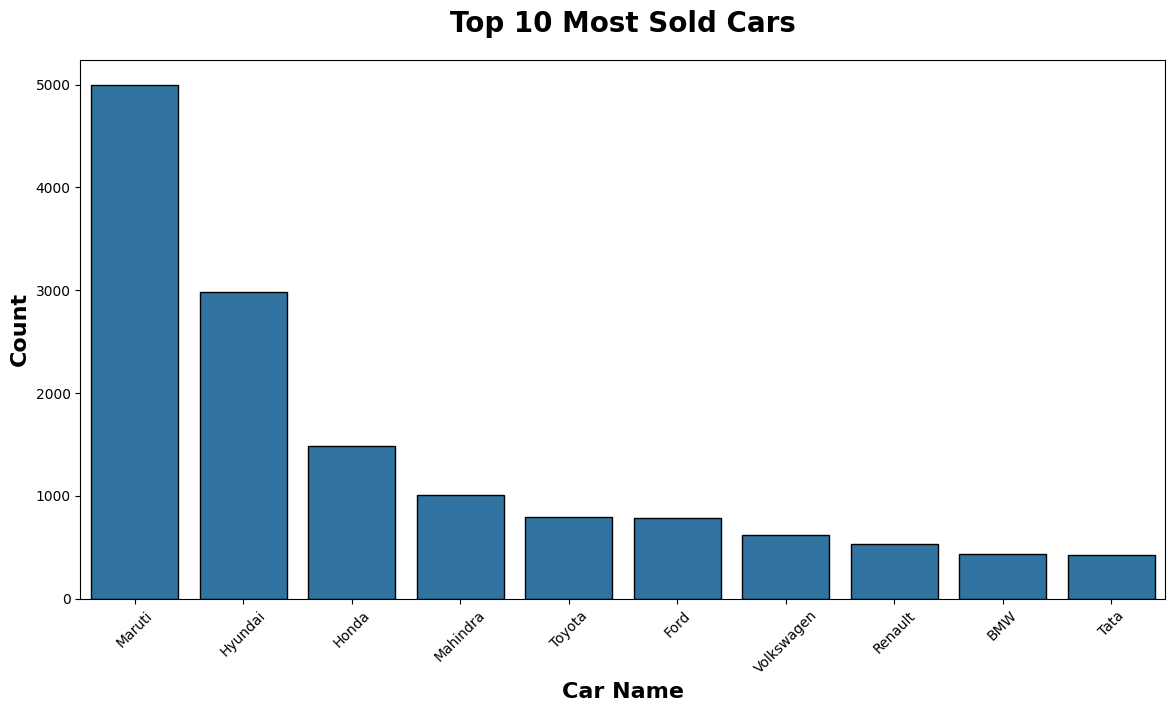

In [ ]:
plt.figure(figsize=(14,7))

sns.countplot(
    x='brand',
    data=df,
    ec='black',
    order=df['brand'].value_counts().head(10).index
)

plt.title('Top 10 Most Sold Cars', weight='bold', fontsize=20, pad=20)
plt.ylabel('Count', weight='bold', fontsize=16)
plt.xlabel('Car Name', weight='bold', fontsize=16)
plt.xticks(rotation=45)
plt.show()

In [ ]:
#Checkmean price of Maruti brand which is most used
maruti=df[df['brand'] == 'Maruti']['selling_price'].mean()
print(f'The mean price of Maruti brand is {maruti:.2f} Rupees')

The mean price of Maruti brand is 487089.32 Rupees


In [ ]:
#Costliest brand and costliest car
brand=df.groupby('brand').selling_price.max()
brand_df=brand.to_frame().sort_values('selling_price',ascending=False)[0:10]
brand_df

,selling_price
brand,
Ferrari,39500000
Rolls-Royce,24200000
Bentley,14500000
Mercedes-Benz,13000000
Porsche,11100000
Land Rover,9200000
BMW,8500000
Volvo,8195000
Lexus,8000000


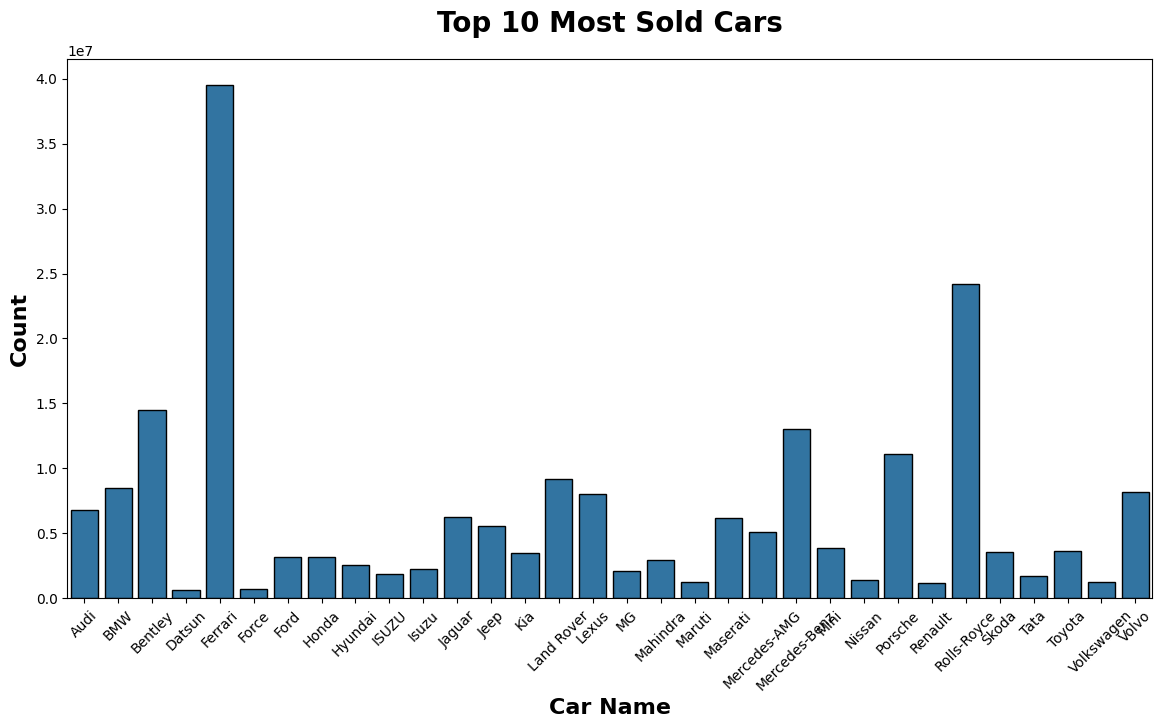

In [ ]:
plt.figure(figsize=(14,7))

sns.barplot(x=brand.index,y=brand.values,ec='black')
plt.title('Top 10 Most Sold Cars', weight='bold', fontsize=20, pad=20)
plt.ylabel('Count', weight='bold', fontsize=16)
plt.xlabel('Car Name', weight='bold', fontsize=16)
plt.xticks(rotation=45)
plt.show()

In [ ]:
#Most milage brand and car name
mileage=df.groupby('brand')['mileage'].mean().sort_values(ascending=False).head(15)
mileage.to_frame()


,mileage
brand,
Maruti,22.430980
Renault,22.099142
Datsun,21.215647
Lexus,20.846000
Ford,19.922620
Honda,19.908795
Maserati,19.820000
Tata,19.755279
Hyundai,19.588776


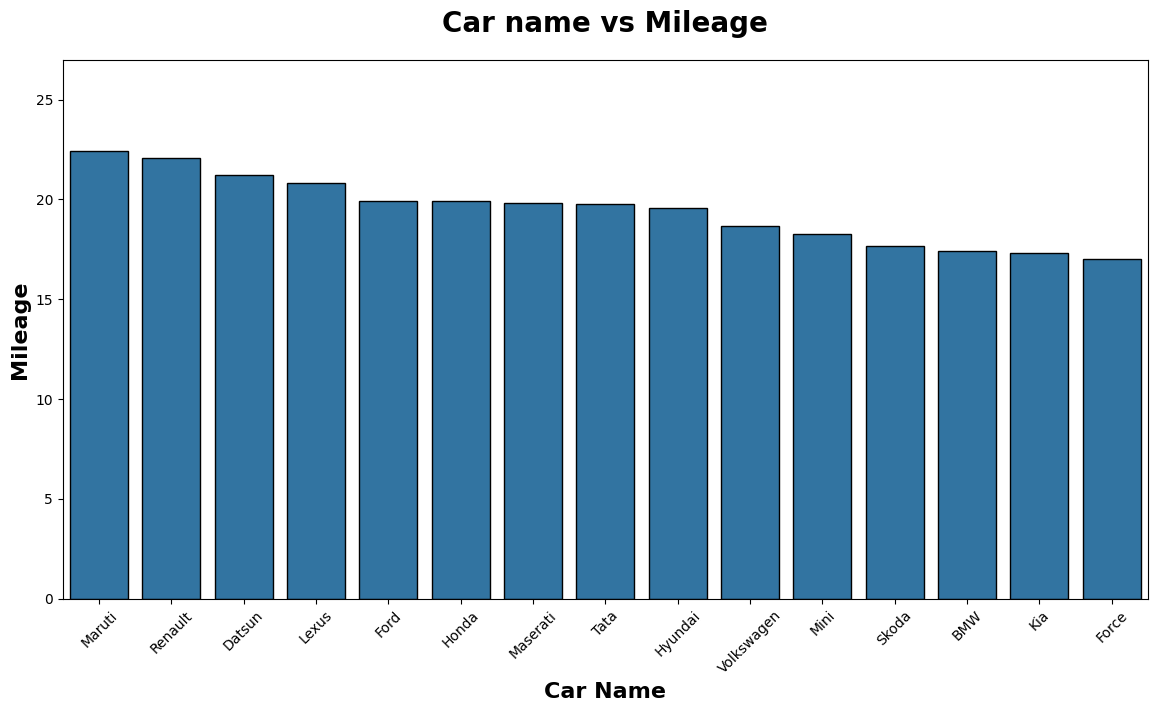

In [ ]:
plt.figure(figsize=(14,7))

sns.barplot(x=mileage.index,y=mileage.values,ec='black')
plt.title('Car name vs Mileage', weight='bold', fontsize=20, pad=20)
plt.ylabel('Mileage', weight='bold', fontsize=16)
plt.xlabel('Car Name', weight='bold', fontsize=16)
plt.ylim(0,27)
plt.xticks(rotation=45)
plt.show()

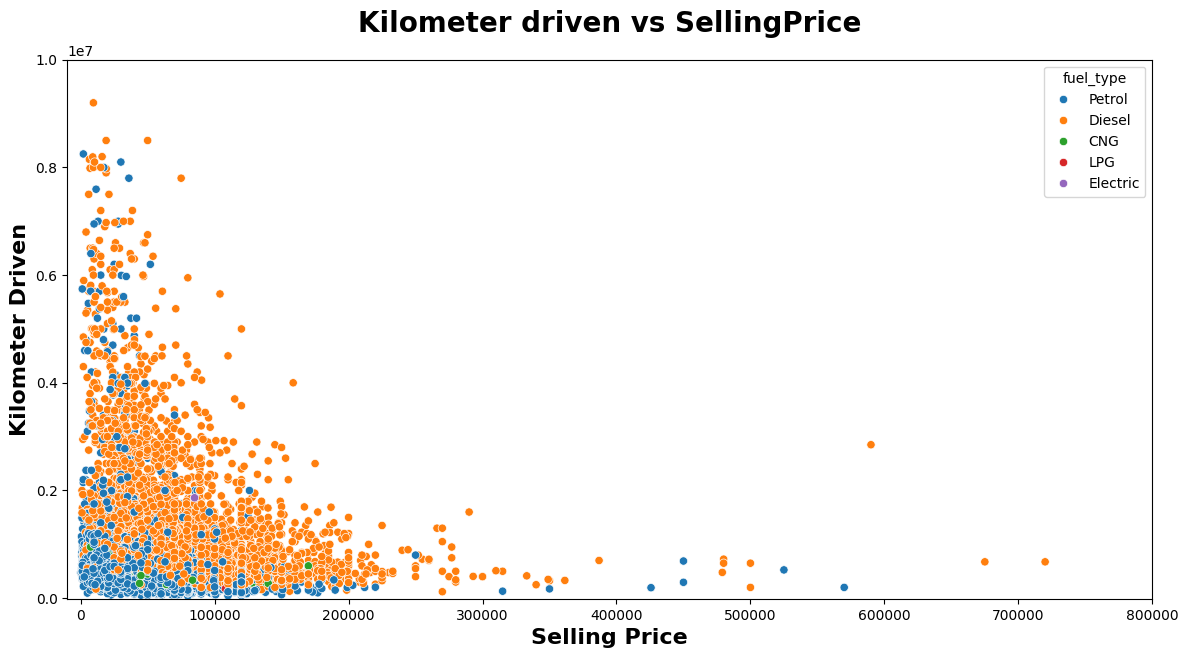

In [ ]:
#Kilometer driven vs selling price
plt.figure(figsize=(14,7))
sns.scatterplot(x='km_driven',y='selling_price',data=df,ec='white',color='b',hue='fuel_type')
plt.title('Kilometer driven vs SellingPrice', weight='bold', fontsize=20, pad=20)
plt.ylabel('Kilometer Driven', weight='bold', fontsize=16)
plt.ylim(-10000,10000000)
plt.xlim(-10000,800000)
plt.xlabel('Selling Price', weight='bold', fontsize=16)
plt.show()

In [ ]:
#fuel type selling price
fuel=df.groupby('fuel_type')['selling_price'].median().sort_values(ascending=False).head(15)
fuel.to_frame()

,selling_price
fuel_type,
Electric,1857500.0
Diesel,700000.0
Petrol,460000.0
CNG,370000.0
LPG,182500.0


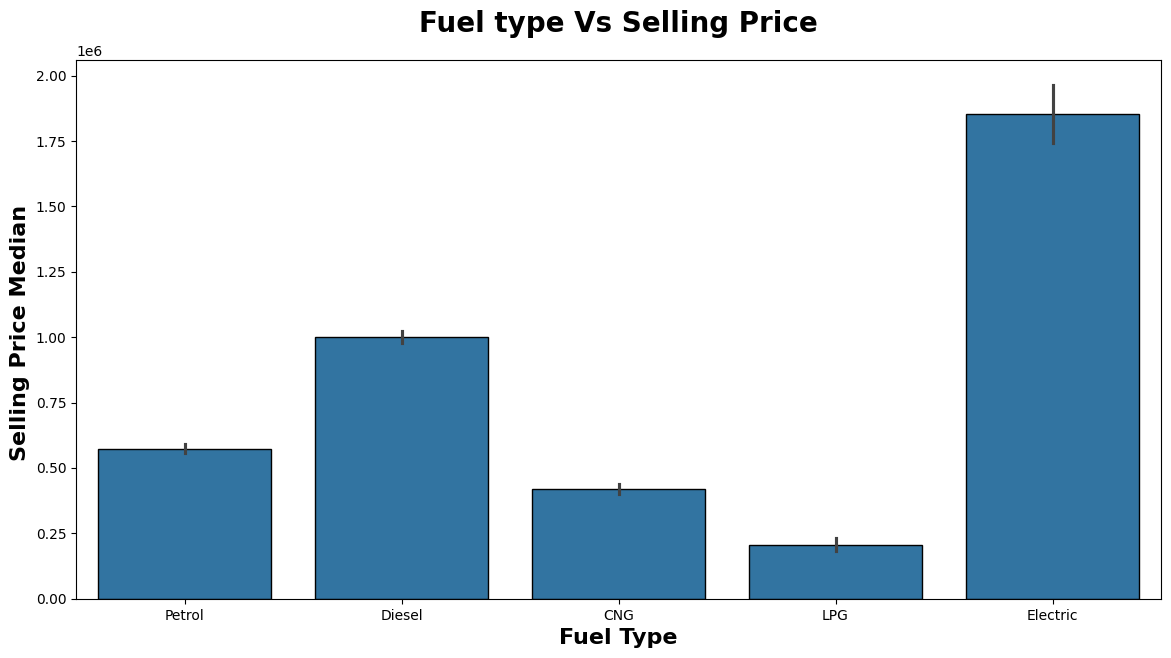

In [ ]:
plt.figure(figsize=(14,7))

sns.barplot(x=df.fuel_type,y=df.selling_price,ec='black')
plt.title('Fuel type Vs Selling Price', weight='bold', fontsize=20, pad=20)
plt.ylabel('Selling Price Median ', weight='bold', fontsize=16)
plt.xlabel('Fuel Type', weight='bold', fontsize=16)
plt.show()

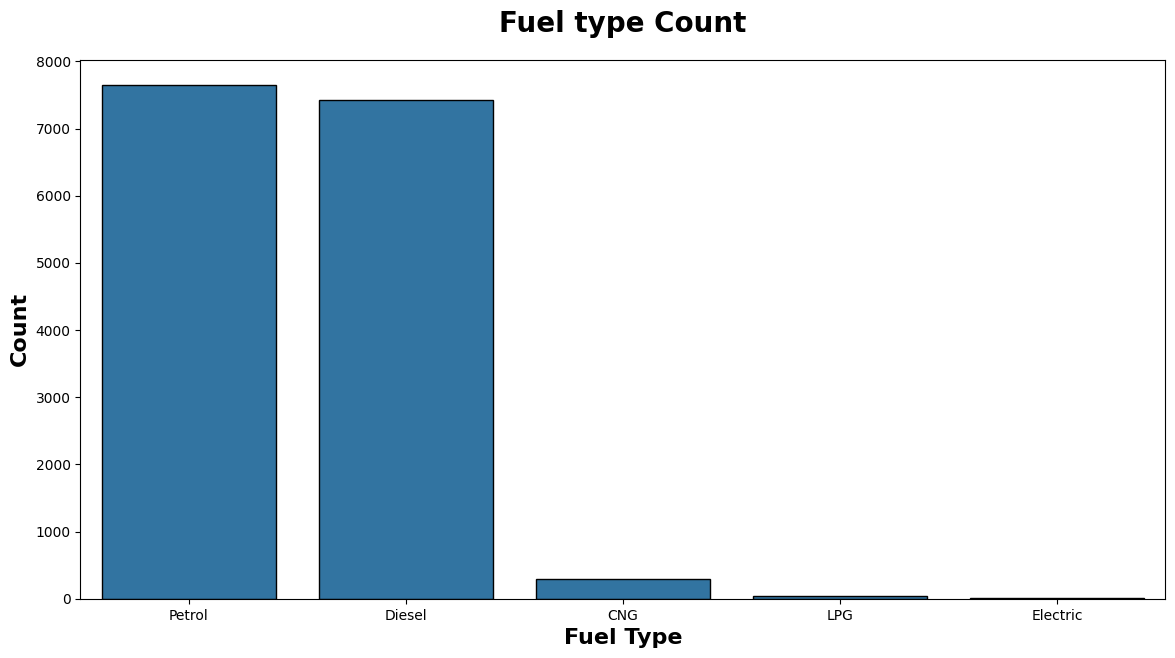

In [ ]:
#Most sold fuel type
plt.subplots(figsize=(14,7))
sns.countplot(x=df.fuel_type,ec='black')
plt.title('Fuel type Count', weight='bold', fontsize=20, pad=20)
plt.ylabel('Count', weight='bold', fontsize=16)
plt.xlabel('Fuel Type', weight='bold', fontsize=16)
plt.show()

In [ ]:
#Mean mileage by fuel type  Q
fuel_mileage=df.groupby('fuel_type')['mileage'].mean().sort_values(ascending=False)
fuel_mileage.to_frame()

,mileage
fuel_type,
CNG,25.814651
Diesel,20.060030
Electric,19.160000
Petrol,19.123045
LPG,17.836364


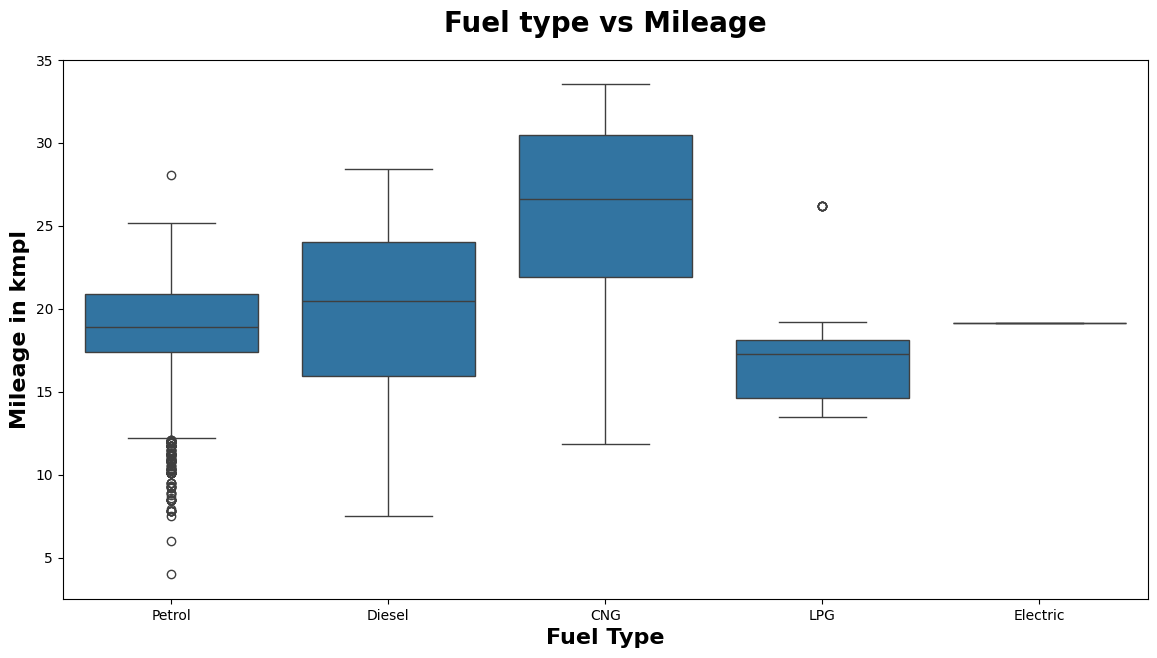

In [ ]:
plt.subplots(figsize=(14,7))
sns.boxplot(x='fuel_type',y='mileage',data=df)
plt.title('Fuel type vs Mileage', weight='bold', fontsize=20, pad=20)
plt.ylabel('Mileage in kmpl', weight='bold', fontsize=16)
plt.xlabel('Fuel Type', weight='bold', fontsize=16)
plt.show()

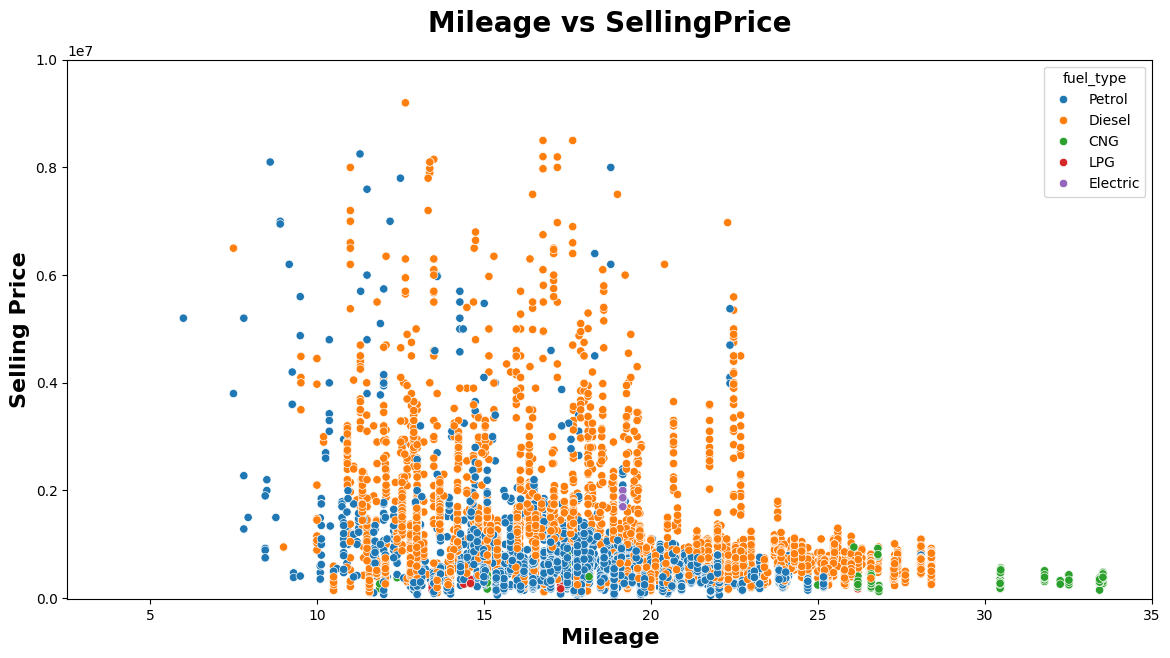

In [ ]:
#Mileage vs Selling price
plt.subplots(figsize=(14,7))
sns.scatterplot(x='mileage',y='selling_price',data=df,ec='white',color='b',hue='fuel_type')
plt.title('Mileage vs SellingPrice', weight='bold', fontsize=20, pad=20)
plt.ylabel('Selling Price', weight='bold', fontsize=16)
plt.ylim(-10000,10000000)
plt.xlabel('Mileage', weight='bold', fontsize=16)
plt.show()

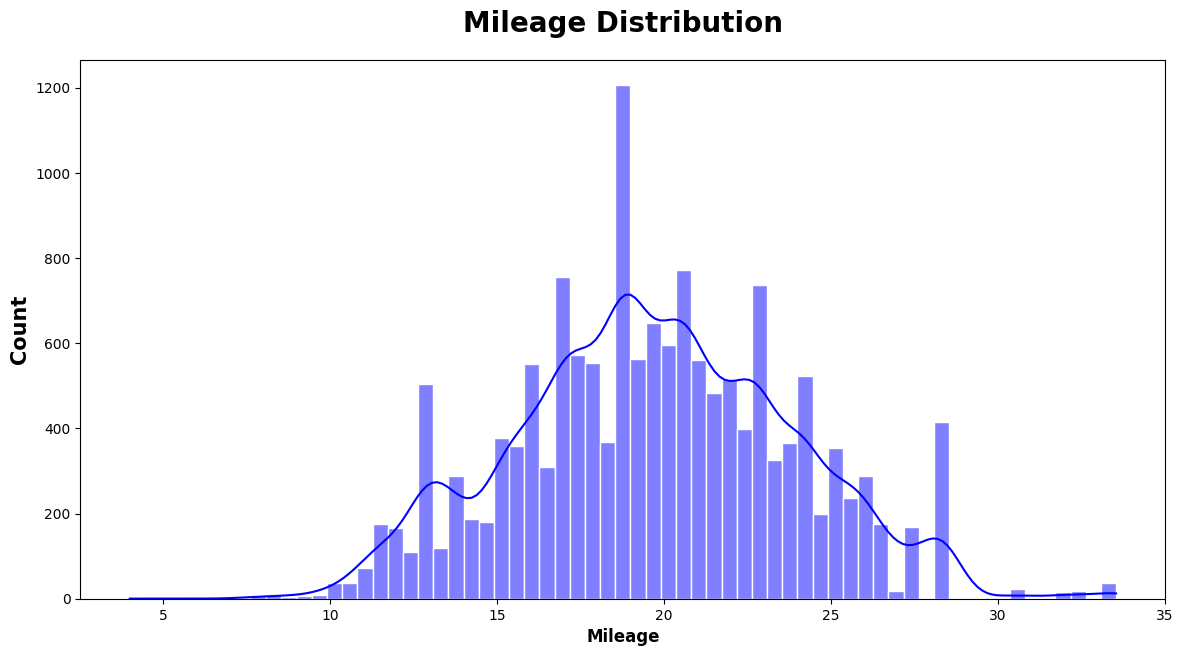

In [ ]:
plt.subplots(figsize=(14,7))
sns.histplot(x=df.mileage,data=df,ec='white',color='b',kde=True)
plt.title('Mileage Distribution', weight='bold', fontsize=20, pad=20)
plt.ylabel('Count', weight='bold', fontsize=15)
plt.xlabel('Mileage', weight='bold', fontsize=12)
plt.show()

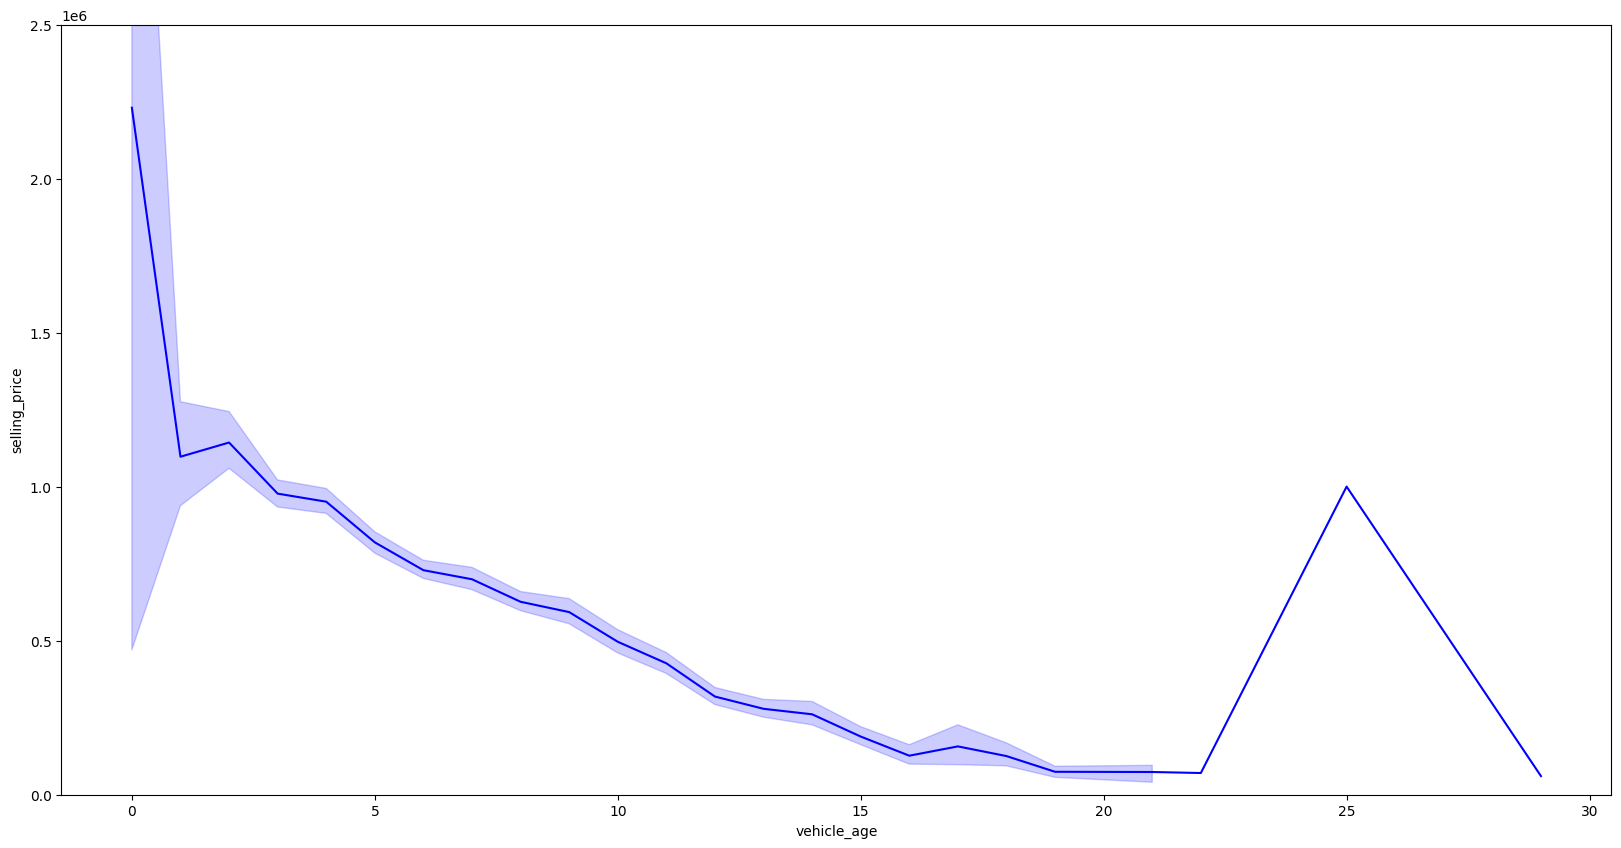

In [ ]:
#Vehicle age vs selling price
plt.subplots(figsize=(20,10))
sns.lineplot(x='vehicle_age',y='selling_price',data=df,color='b')
plt.ylim(0,2500000)
plt.show()

In [ ]:
#Vehicle age vs mileage
vehicle_age=df.groupby('vehicle_age')['mileage'].median().sort_values(ascending=False)
vehicle_age.to_frame()

,mileage
vehicle_age,
29,22.05
0,21.70
3,21.21
4,20.63
5,20.51
6,20.14
7,20.00
1,20.00
2,19.60


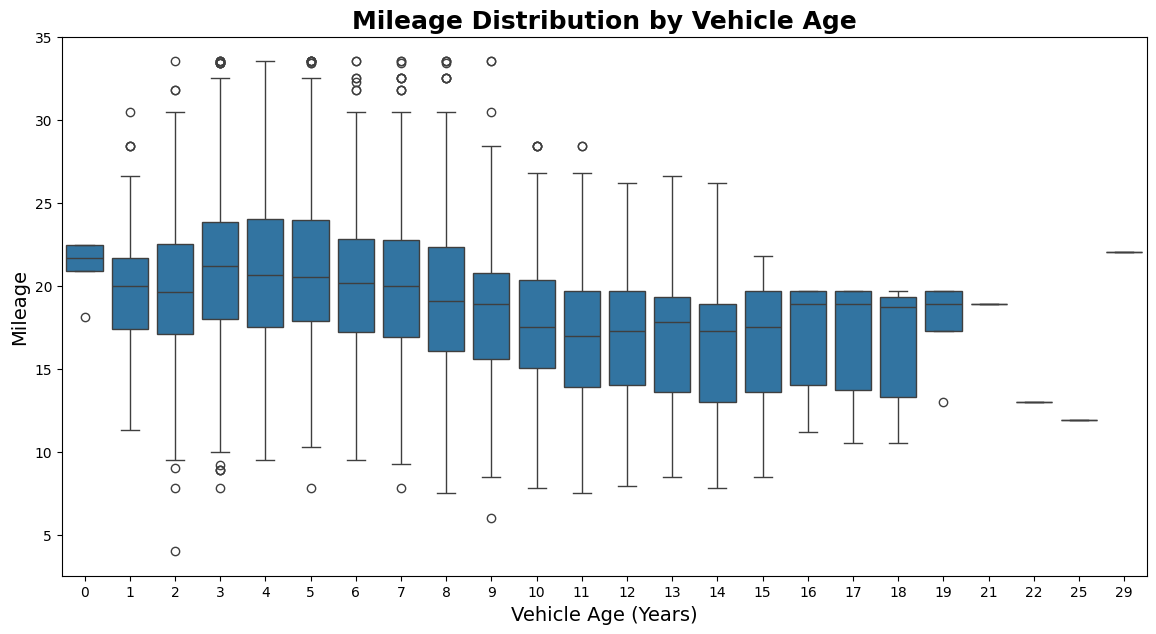

In [ ]:
plt.figure(figsize=(14,7))

sns.boxplot(
    x='vehicle_age',
    y='mileage',
    data=df
)

plt.title('Mileage Distribution by Vehicle Age', fontsize=18, weight='bold')
plt.xlabel('Vehicle Age (Years)', fontsize=14)
plt.ylabel('Mileage', fontsize=14)
plt.show()


In [ ]:
oldest=df.groupby('car_name')['vehicle_age'].max().sort_values(ascending=False).head(10)
oldest.to_frame()

,vehicle_age
car_name,
Maruti Alto,29
BMW 3,25
Honda City,22
Maruti Wagon R,21
Mahindra Scorpio,18
Mahindra Bolero,18
Skoda Octavia,18
Mercedes-Benz E-Class,17
Honda CR-V,17


<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

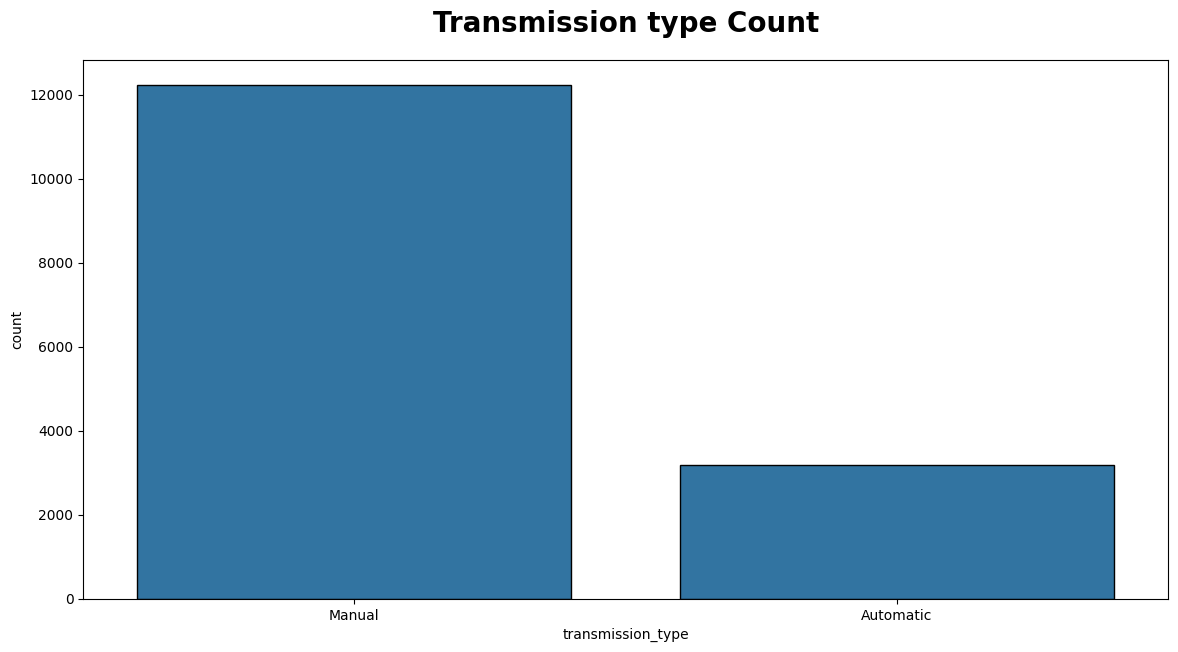

In [ ]:
#Transmission type
plt.subplots(figsize=(14,7))
sns.countplot(x=df.transmission_type,ec='black',data=df)
plt.title('Transmission type Count', weight='bold', fontsize=20, pad=20)
plt

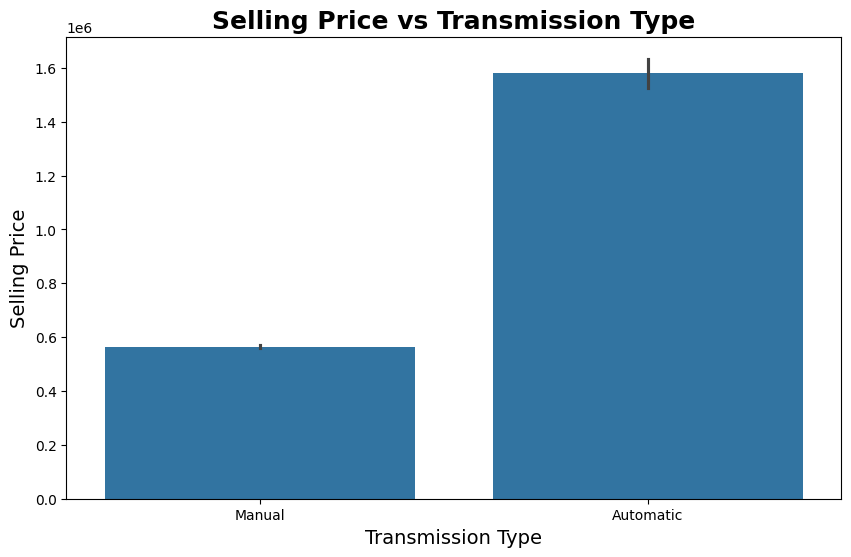

In [ ]:
#Transmission type vs Selling price
plt.figure(figsize=(10,6))

sns.barplot(
    x='transmission_type',
    y='selling_price',
    data=df
)

plt.title('Selling Price vs Transmission Type', fontsize=18, weight='bold')
plt.xlabel('Transmission Type', fontsize=14)
plt.ylabel('Selling Price', fontsize=14)

plt.show()


In [ ]:
dealer=df.groupby('seller_type')['selling_price'].median().sort_values(ascending=False)
dealer.to_frame()

,selling_price
seller_type,
Dealer,591000.0
Trustmark Dealer,540000.0
Individual,507000.0


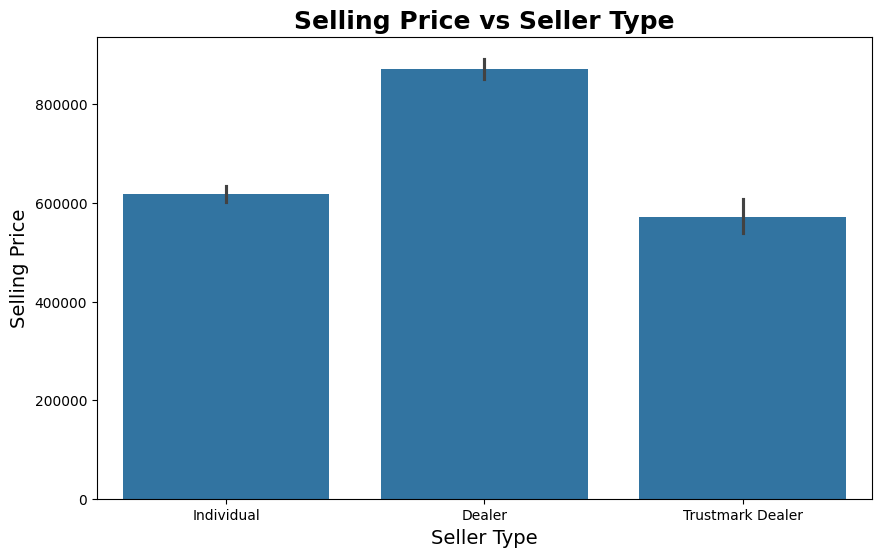

In [ ]:
#Seller Type
plt.figure(figsize=(10,6))

sns.barplot(
    x='seller_type',
    y='selling_price',
    data=df
)

plt.title('Selling Price vs Seller Type', fontsize=18, weight='bold')
plt.xlabel('Seller Type', fontsize=14)
plt.ylabel('Selling Price', fontsize=14)

plt.show()


**Report**

- Dealers have put more ads on used car website.

- Dealers have put 9539 ads with a median selling price of 5.91 Lakhs.

- Followed by Individuals with 5699 ads with median selling price of 5.4 Lakhs.

- Dealers have more median selling price than Individuals.

**Final Report**

- The datatypes and column names were right and there were 15,411 rows and 13 columns.

- The selling_price column is the target to predict, i.e., a Regression Problem.

- There are outliers in km_driven, engine, selling_price, and max_power.

- Dealers are the highest sellers of used cars.

- Skewness is found in a few columns, we will check it after handling outliers.

- Vehicle age has a negative impact on price.

- Manual cars are mostly sold, and automatic cars have a higher average selling price than manual cars.

- Petrol is the most preferred fuel choice on the used car website, followed by Diesel and LPG.

- We just need less data cleaning for this dataset.

- From EDA, Brand and Model have the same information as Carname. Hence, we can drop Brand and Model columns and retain Carname.